## Compare cancer mondo branch vs model stat

In [13]:
import pandas as pd

cancer_terms = set(pd.read_csv("data/cancer_terms.csv")["mondo_id"])
print("Cancer terms (full MONDO):", len(cancer_terms))

model_stats = pd.read_csv("data/disease_model_stats.csv")
model_stats["mondo_id"] = model_stats["ID"].str.replace("MONDO:", "MONDO_", regex=False)
model_terms = set(model_stats["mondo_id"])

print("Model terms total:", len(model_terms))

cancer_available = cancer_terms & model_terms
cancer_missing = cancer_terms - model_terms

print("Cancer terms with model:", len(cancer_available))
print("Cancer terms missing model:", len(cancer_missing))

print("Coverage rate:", len(cancer_available) / len(cancer_terms))

pd.DataFrame({"mondo_id": sorted(cancer_available)}).to_csv("data/cancer_model_terms.csv", index=False)

Cancer terms (full MONDO): 2270
Model terms total: 1166
Cancer terms with model: 261
Cancer terms missing model: 2009
Coverage rate: 0.11497797356828193


In [14]:
import pandas as pd
from collections import defaultdict, deque

# 读数据
terms_df = pd.read_csv("data/cancer_model_terms.csv")
edges_df = pd.read_csv("data/cancer_model_edges.csv")

ROOT = "MONDO_0004992"

terms = set(terms_df["mondo_id"])
print("Terms:", len(terms))
print("Edges:", edges_df.shape[0])

# 构建 parent / children map
parents = defaultdict(set)
children = defaultdict(set)

for _, row in edges_df.iterrows():
    c = row["child"]
    p = row["parent"]
    parents[c].add(p)
    children[p].add(c)

Terms: 261
Edges: 382


In [15]:
# 计算 depth
depth = {ROOT: 0}
queue = deque([ROOT])

while queue:
    current = queue.popleft()
    for ch in children.get(current, []):
        if ch not in depth:
            depth[ch] = depth[current] + 1
            queue.append(ch)

print("Max depth:", max(depth.values()))
print("Depth distribution:")
print(pd.Series(depth.values()).value_counts().sort_index())

human_strong = pd.read_csv("results/human_strong_preds.csv")
mouse_strong = pd.read_csv("results/mouse_strong_preds.csv")

human_strong = human_strong[human_strong["mondo_id"].isin(terms)]
mouse_strong = mouse_strong[mouse_strong["mondo_id"].isin(terms)]

human_strong["depth"] = human_strong["mondo_id"].map(depth)
mouse_strong["depth"] = mouse_strong["mondo_id"].map(depth)

print("Human depth distribution:")
print(human_strong["depth"].value_counts().sort_index())

print("Mouse depth distribution:")
print(mouse_strong["depth"].value_counts().sort_index())

print("Human mean depth:", human_strong["depth"].mean())
print("Mouse mean depth:", mouse_strong["depth"].mean())

Max depth: 7
Depth distribution:
0     1
1    25
2    77
3    95
4    46
5    12
6     4
7     1
Name: count, dtype: int64
Human depth distribution:
depth
1     41
2    255
3    159
4     39
5     60
Name: count, dtype: int64
Mouse depth distribution:
depth
1    20
2    84
3    38
4    18
5    37
Name: count, dtype: int64
Human mean depth: 2.67870036101083
Mouse mean depth: 2.8375634517766497


In [16]:
human_term_freq = human_strong["mondo_id"].value_counts()
mouse_term_freq = mouse_strong["mondo_id"].value_counts()

print("Top 10 human terms:")
print(human_term_freq.head(10))

print("\nTop 10 mouse terms:")
print(mouse_term_freq.head(10))

import numpy as np

def gini(x):
    x = np.array(x)
    x = x[x > 0]
    x = np.sort(x)
    n = len(x)
    return (np.sum((2*np.arange(1,n+1)-n-1)*x))/(n*np.sum(x))

print("Human term Gini:", gini(human_term_freq.values))
print("Mouse term Gini:", gini(mouse_term_freq.values))

human_depth_freq = human_strong.groupby("depth")["mondo_id"].count()
mouse_depth_freq = mouse_strong.groupby("depth")["mondo_id"].count()

print("Human depth freq:")
print(human_depth_freq)

print("\nMouse depth freq:")
print(mouse_depth_freq)

human_depth_prop = human_depth_freq / human_depth_freq.sum()
mouse_depth_prop = mouse_depth_freq / mouse_depth_freq.sum()

active_human = set(human_strong["mondo_id"])
active_mouse = set(mouse_strong["mondo_id"])

print("Active nodes (human):", len(active_human))
print("Active nodes (mouse):", len(active_mouse))
print("Total available nodes:", len(terms))

depth_term_count = pd.Series(depth).value_counts()

depth_active_human = human_strong.groupby("depth")["mondo_id"].nunique()

print("Depth-level node usage (human):")
print(depth_active_human / depth_term_count)

ROOT = "MONDO_0004992"

print("Human root freq:", human_term_freq.get(ROOT, 0))
print("Mouse root freq:", mouse_term_freq.get(ROOT, 0))

human_depth_score = human_strong.groupby("depth")["log2(prob/prior)"].mean()
mouse_depth_score = mouse_strong.groupby("depth")["log2(prob/prior)"].mean()

print("Human mean score by depth:")
print(human_depth_score)

print("\nMouse mean score by depth:")
print(mouse_depth_score)

Top 10 human terms:
mondo_id
MONDO_0004989    117
MONDO_0018874     42
MONDO_0008315     33
MONDO_0007254     27
MONDO_0009831     21
MONDO_0018177     19
MONDO_0005575     18
MONDO_0011996     17
MONDO_0016680     15
MONDO_0007256     14
Name: count, dtype: int64

Top 10 mouse terms:
mondo_id
MONDO_0018874    32
MONDO_0009831    30
MONDO_0008315    11
MONDO_0005061     9
MONDO_0005089     8
MONDO_0100342     7
MONDO_0004989     7
MONDO_0001056     7
MONDO_0005096     7
MONDO_0004643     6
Name: count, dtype: int64
Human term Gini: 0.6150513746181616
Mouse term Gini: 0.5387793648919844
Human depth freq:
depth
1     41
2    255
3    159
4     39
5     60
Name: mondo_id, dtype: int64

Mouse depth freq:
depth
1    20
2    84
3    38
4    18
5    37
Name: mondo_id, dtype: int64
Active nodes (human): 65
Active nodes (mouse): 43
Total available nodes: 261
Depth-level node usage (human):
0         NaN
1    0.440000
2    0.259740
3    0.242105
4    0.173913
5    0.250000
6         NaN
7       

In [17]:
human_top5_share = human_term_freq.head(5).sum() / human_term_freq.sum()
mouse_top5_share = mouse_term_freq.head(5).sum() / mouse_term_freq.sum()

print("Human top5 share:", human_top5_share)
print("Mouse top5 share:", mouse_top5_share)

import scipy.stats as stats

depth_usage = (human_depth_freq / human_depth_freq.sum())
corr = stats.spearmanr(depth_usage.index, depth_usage.values)
print("Spearman depth vs usage:", corr)

Human top5 share: 0.4332129963898917
Mouse top5 share: 0.45685279187817257
Spearman depth vs usage: SignificanceResult(statistic=np.float64(-0.19999999999999998), pvalue=np.float64(0.747060078104662))


In [18]:
import pandas as pd
import numpy as np

# -----------------------------
# 0) 准备：只保留 cancer branch 内 strong hits
# -----------------------------
human_cancer = human_strong[human_strong["mondo_id"].isin(cancer_terms)].copy()
mouse_cancer = mouse_strong[mouse_strong["mondo_id"].isin(cancer_terms)].copy()

print("Human cancer strong rows:", human_cancer.shape)
print("Mouse cancer strong rows:", mouse_cancer.shape)

# 每个 GSE 的 strong-hit 集合
human_hit_map = human_cancer.groupby("ID")["mondo_id"].apply(set).to_dict()
mouse_hit_map = mouse_cancer.groupby("ID")["mondo_id"].apply(set).to_dict()

print("Human cancer IDs:", len(human_hit_map))
print("Mouse cancer IDs:", len(mouse_hit_map))


# -----------------------------
# 1) direct parent consistency
# 问：child 命中时，它的 direct parent 是否也命中？
# -----------------------------
def direct_parent_consistency(df, hit_map, name):
    rows = []

    for _, row in df.iterrows():
        gse_id = row["ID"]
        child = row["mondo_id"]
        child_score = row["log2(prob/prior)"]

        direct_parents = [p for p in parents.get(child, set()) if p in cancer_terms]
        hits = hit_map.get(gse_id, set())

        # 没有 direct parent（例如 root）就跳过
        if len(direct_parents) == 0:
            continue

        for p in direct_parents:
            rows.append({
                "ID": gse_id,
                "child": child,
                "parent": p,
                "child_score": child_score,
                "parent_hit": p in hits
            })

    out = pd.DataFrame(rows)
    print(f"\n--- {name}: direct parent consistency ---")
    print("Rows:", out.shape[0])

    if len(out) > 0:
        print("Parent-hit rate:", out["parent_hit"].mean())
        print("Child terms involved:", out["child"].nunique())
        print("Parent terms involved:", out["parent"].nunique())
    else:
        print("No evaluable rows")

    return out

human_parent_check = direct_parent_consistency(human_cancer, human_hit_map, "Human")
mouse_parent_check = direct_parent_consistency(mouse_cancer, mouse_hit_map, "Mouse")


# 可选：看哪些 child 最常出现 parent missing
def summarize_parent_failures(parent_df, name, topn=20):
    if len(parent_df) == 0:
        return

    fail = parent_df[~parent_df["parent_hit"]].copy()

    print(f"\n--- {name}: top child terms with missing direct parent ---")
    if len(fail) == 0:
        print("No failures")
        return

    print(fail["child"].value_counts().head(topn))

summarize_parent_failures(human_parent_check, "Human")
summarize_parent_failures(mouse_parent_check, "Mouse")


# -----------------------------
# 2) ancestor coverage
# 问：如果一个 child 命中，它全部 ancestors 里有多少也被命中？
# coverage = |ancestors ∩ hits| / |ancestors|
# -----------------------------
def ancestor_coverage(df, hit_map, name):
    rows = []

    for _, row in df.iterrows():
        gse_id = row["ID"]
        term = row["mondo_id"]
        score = row["log2(prob/prior)"]

        anc = set(ancestors(term))
        anc = {a for a in anc if a in cancer_terms}

        # root 或没有祖先的 term 跳过
        if len(anc) == 0:
            continue

        hits = hit_map.get(gse_id, set())
        anc_hit = anc & hits

        rows.append({
            "ID": gse_id,
            "term": term,
            "score": score,
            "n_ancestors": len(anc),
            "n_ancestors_hit": len(anc_hit),
            "coverage": len(anc_hit) / len(anc)
        })

    out = pd.DataFrame(rows)
    print(f"\n--- {name}: ancestor coverage ---")
    print("Rows:", out.shape[0])

    if len(out) > 0:
        print("Mean coverage:", out["coverage"].mean())
        print("Median coverage:", out["coverage"].median())
        print("Coverage >= 0.8:", (out["coverage"] >= 0.8).mean())
        print("Coverage = 1.0:", (out["coverage"] == 1.0).mean())
    else:
        print("No evaluable rows")

    return out

human_ancestor_cov = ancestor_coverage(human_cancer, human_hit_map, "Human")
mouse_ancestor_cov = ancestor_coverage(mouse_cancer, mouse_hit_map, "Mouse")


# depth 分层看 coverage
def coverage_by_depth(cov_df, depth_map, name):
    if len(cov_df) == 0:
        return pd.DataFrame()

    tmp = cov_df.copy()
    tmp["depth"] = tmp["term"].map(depth_map)

    summary = tmp.groupby("depth")["coverage"].agg(["count", "mean", "median"])
    print(f"\n--- {name}: ancestor coverage by depth ---")
    print(summary)
    return summary

human_cov_depth = coverage_by_depth(human_ancestor_cov, depth, "Human")
mouse_cov_depth = coverage_by_depth(mouse_ancestor_cov, depth, "Mouse")


# -----------------------------
# 3) edge-level monotonicity
# 问：沿 child -> parent，score(child) 是否通常 > score(parent)？
# 这里要用完整 prediction matrix，不只是 strong top1
# -----------------------------
def load_all_preds(fp):
    df = pd.read_csv(fp)
    df["mondo_id"] = df["model"].str.replace("__preds", "", regex=False)
    return df

human_all = load_all_preds("results/meta/human_title_summary_preds.csv")
mouse_all = load_all_preds("results/meta/mouse_title_summary_preds.csv")

human_all = human_all[human_all["mondo_id"].isin(cancer_terms)].copy()
mouse_all = mouse_all[mouse_all["mondo_id"].isin(cancer_terms)].copy()

print("\nHuman all cancer preds:", human_all.shape)
print("Mouse all cancer preds:", mouse_all.shape)


def edge_monotonicity(all_df, strong_df, name):
    # 所有 cancer scores 做成 lookup
    score_map = all_df.set_index(["ID", "mondo_id"])["log2(prob/prior)"].to_dict()

    rows = []

    # 只对 strong child hits 检查
    for _, row in strong_df.iterrows():
        gse_id = row["ID"]
        child = row["mondo_id"]
        child_score = row["log2(prob/prior)"]

        direct_parents = [p for p in parents.get(child, set()) if p in cancer_terms]
        if len(direct_parents) == 0:
            continue

        for p in direct_parents:
            parent_score = score_map.get((gse_id, p), np.nan)
            delta = child_score - parent_score if pd.notna(parent_score) else np.nan

            rows.append({
                "ID": gse_id,
                "child": child,
                "parent": p,
                "child_score": child_score,
                "parent_score": parent_score,
                "delta_child_minus_parent": delta,
                "child_gt_parent": pd.notna(delta) and (delta > 0),
                "parent_positive": pd.notna(parent_score) and (parent_score > 0),
                "parent_strong": pd.notna(parent_score) and (parent_score >= THRESH)
            })

    out = pd.DataFrame(rows)

    print(f"\n--- {name}: edge-level monotonicity ---")
    print("Rows:", out.shape[0])

    valid = out.dropna(subset=["delta_child_minus_parent"]).copy()
    print("Valid rows:", valid.shape[0])

    if len(valid) > 0:
        print("Mean delta:", valid["delta_child_minus_parent"].mean())
        print("Median delta:", valid["delta_child_minus_parent"].median())
        print("child > parent rate:", valid["child_gt_parent"].mean())
        print("parent positive rate:", valid["parent_positive"].mean())
        print("parent strong rate:", valid["parent_strong"].mean())
    else:
        print("No valid rows")

    return out

human_edge_delta = edge_monotonicity(human_all, human_cancer, "Human")
mouse_edge_delta = edge_monotonicity(mouse_all, mouse_cancer, "Mouse")


# -----------------------------
# 4) 违反单调性的反例
# -----------------------------
def show_monotonicity_failures(edge_df, name, topn=20):
    valid = edge_df.dropna(subset=["delta_child_minus_parent"]).copy()
    fail = valid[valid["delta_child_minus_parent"] <= 0].copy()

    print(f"\n--- {name}: monotonicity failures (top {topn}) ---")
    if len(fail) == 0:
        print("No failures")
        return fail

    fail = fail.sort_values("delta_child_minus_parent").head(topn)
    print(fail[["ID", "child", "parent", "child_score", "parent_score", "delta_child_minus_parent"]])
    return fail

human_fail = show_monotonicity_failures(human_edge_delta, "Human", topn=20)
mouse_fail = show_monotonicity_failures(mouse_edge_delta, "Mouse", topn=20)


# -----------------------------
# 5) 可选：branch purity / hit dispersion
# 先做一个最简单版本：
# 一个 GSE 的 cancer strong hits 数量，以及这些 hits 的 deepest depth / unique depths
# -----------------------------
def branch_purity_basic(df, name):
    tmp = df.copy()
    tmp["depth"] = tmp["mondo_id"].map(depth)

    summary = tmp.groupby("ID").agg(
        n_hits=("mondo_id", "nunique"),
        n_depths=("depth", "nunique"),
        max_depth=("depth", "max"),
        mean_score=("log2(prob/prior)", "mean"),
        max_score=("log2(prob/prior)", "max")
    ).reset_index()

    print(f"\n--- {name}: branch purity basic ---")
    print(summary.describe(include="all"))

    return summary

human_branch_basic = branch_purity_basic(human_cancer, "Human")
mouse_branch_basic = branch_purity_basic(mouse_cancer, "Mouse")


# -----------------------------
# 6) 保存输出，方便后面写结果
# -----------------------------
human_parent_check.to_csv("results/cancer_human_direct_parent_check.csv", index=False)
mouse_parent_check.to_csv("results/cancer_mouse_direct_parent_check.csv", index=False)

human_ancestor_cov.to_csv("results/cancer_human_ancestor_coverage.csv", index=False)
mouse_ancestor_cov.to_csv("results/cancer_mouse_ancestor_coverage.csv", index=False)

human_edge_delta.to_csv("results/cancer_human_edge_monotonicity.csv", index=False)
mouse_edge_delta.to_csv("results/cancer_mouse_edge_monotonicity.csv", index=False)

human_branch_basic.to_csv("results/cancer_human_branch_basic.csv", index=False)
mouse_branch_basic.to_csv("results/cancer_mouse_branch_basic.csv", index=False)

print("\nSaved all Layer 2 outputs.")

Human cancer strong rows: (554, 6)
Mouse cancer strong rows: (197, 6)
Human cancer IDs: 554
Mouse cancer IDs: 197

--- Human: direct parent consistency ---
Rows: 765
Parent-hit rate: 0.0
Child terms involved: 65
Parent terms involved: 50

--- Mouse: direct parent consistency ---
Rows: 235
Parent-hit rate: 0.0
Child terms involved: 43
Parent terms involved: 37

--- Human: top child terms with missing direct parent ---
child
MONDO_0004989    234
MONDO_0018874     42
MONDO_0008315     33
MONDO_0007256     28
MONDO_0007254     27
MONDO_0024331     24
MONDO_0005061     24
MONDO_0009831     21
MONDO_0018177     19
MONDO_0008903     18
MONDO_0005575     18
MONDO_0100342     18
MONDO_0011996     17
MONDO_0016680     15
MONDO_0015075     12
MONDO_0005008     12
MONDO_0008170     11
MONDO_0005814     11
MONDO_0005089     11
MONDO_0002108      9
Name: count, dtype: int64

--- Mouse: top child terms with missing direct parent ---
child
MONDO_0018874    32
MONDO_0009831    30
MONDO_0005061    18
MO

In [19]:
import pandas as pd
import numpy as np

# 只保留 cancer branch
human_all_cancer = human_all[human_all["mondo_id"].isin(cancer_terms)].copy()
mouse_all_cancer = mouse_all[mouse_all["mondo_id"].isin(cancer_terms)].copy()

# Top-k strong hits: score >= THRESH
human_cancer_topk = human_all_cancer[human_all_cancer["log2(prob/prior)"] >= THRESH].copy()
mouse_cancer_topk = mouse_all_cancer[mouse_all_cancer["log2(prob/prior)"] >= THRESH].copy()

print("Human Top-k cancer strong rows:", human_cancer_topk.shape)
print("Mouse Top-k cancer strong rows:", mouse_cancer_topk.shape)

print("Human Top-k cancer IDs:", human_cancer_topk["ID"].nunique())
print("Mouse Top-k cancer IDs:", mouse_cancer_topk["ID"].nunique())

Human Top-k cancer strong rows: (6997, 6)
Mouse Top-k cancer strong rows: (2650, 6)
Human Top-k cancer IDs: 982
Mouse Top-k cancer IDs: 472


In [20]:
human_topk_hit_map = human_cancer_topk.groupby("ID")["mondo_id"].apply(set).to_dict()
mouse_topk_hit_map = mouse_cancer_topk.groupby("ID")["mondo_id"].apply(set).to_dict()

# 每个 GSE 有多少 cancer strong hits
human_topk_sizes = human_cancer_topk.groupby("ID")["mondo_id"].nunique()
mouse_topk_sizes = mouse_cancer_topk.groupby("ID")["mondo_id"].nunique()

print("\n--- Top-k hit counts per GSE ---")
print("Human mean hits:", human_topk_sizes.mean())
print("Human median hits:", human_topk_sizes.median())
print("Human max hits:", human_topk_sizes.max())

print("Mouse mean hits:", mouse_topk_sizes.mean())
print("Mouse median hits:", mouse_topk_sizes.median())
print("Mouse max hits:", mouse_topk_sizes.max())


--- Top-k hit counts per GSE ---
Human mean hits: 7.125254582484725
Human median hits: 6.0
Human max hits: 31
Mouse mean hits: 5.614406779661017
Mouse median hits: 6.0
Mouse max hits: 19


In [21]:
def direct_parent_consistency_topk(df, hit_map, name):
    rows = []

    for _, row in df.iterrows():
        gse_id = row["ID"]
        child = row["mondo_id"]
        child_score = row["log2(prob/prior)"]

        direct_parents = [p for p in parents.get(child, set()) if p in cancer_terms]
        hits = hit_map.get(gse_id, set())

        if len(direct_parents) == 0:
            continue

        for p in direct_parents:
            rows.append({
                "ID": gse_id,
                "child": child,
                "parent": p,
                "child_score": child_score,
                "parent_hit": p in hits
            })

    out = pd.DataFrame(rows)

    print(f"\n--- {name}: direct parent consistency (Top-k) ---")
    print("Rows:", out.shape[0])

    if len(out) > 0:
        print("Parent-hit rate:", out["parent_hit"].mean())
        print("Child terms involved:", out["child"].nunique())
        print("Parent terms involved:", out["parent"].nunique())
    else:
        print("No evaluable rows")

    return out

human_parent_check_topk = direct_parent_consistency_topk(
    human_cancer_topk, human_topk_hit_map, "Human"
)

mouse_parent_check_topk = direct_parent_consistency_topk(
    mouse_cancer_topk, mouse_topk_hit_map, "Mouse"
)


--- Human: direct parent consistency (Top-k) ---
Rows: 9710
Parent-hit rate: 0.6925849639546859
Child terms involved: 165
Parent terms involved: 125

--- Mouse: direct parent consistency (Top-k) ---
Rows: 3683
Parent-hit rate: 0.6228617974477328
Child terms involved: 157
Parent terms involved: 121


In [22]:
def ancestor_coverage_topk(df, hit_map, name):
    rows = []

    for _, row in df.iterrows():
        gse_id = row["ID"]
        term = row["mondo_id"]
        score = row["log2(prob/prior)"]

        anc = set(ancestors(term))
        anc = {a for a in anc if a in cancer_terms}

        if len(anc) == 0:
            continue

        hits = hit_map.get(gse_id, set())
        anc_hit = anc & hits

        rows.append({
            "ID": gse_id,
            "term": term,
            "score": score,
            "n_ancestors": len(anc),
            "n_ancestors_hit": len(anc_hit),
            "coverage": len(anc_hit) / len(anc),
        })

    out = pd.DataFrame(rows)

    print(f"\n--- {name}: ancestor coverage (Top-k) ---")
    print("Rows:", out.shape[0])

    if len(out) > 0:
        print("Mean coverage:", out["coverage"].mean())
        print("Median coverage:", out["coverage"].median())
        print("Coverage >= 0.8:", (out["coverage"] >= 0.8).mean())
        print("Coverage = 1.0:", (out["coverage"] == 1.0).mean())
    else:
        print("No evaluable rows")

    return out

human_ancestor_cov_topk = ancestor_coverage_topk(
    human_cancer_topk, human_topk_hit_map, "Human"
)

mouse_ancestor_cov_topk = ancestor_coverage_topk(
    mouse_cancer_topk, mouse_topk_hit_map, "Mouse"
)


--- Human: ancestor coverage (Top-k) ---
Rows: 6997
Mean coverage: 0.46972714730682436
Median coverage: 0.5
Coverage >= 0.8: 0.15978276404173217
Coverage = 1.0: 0.0

--- Mouse: ancestor coverage (Top-k) ---
Rows: 2650
Mean coverage: 0.42552904380734563
Median coverage: 0.5
Coverage >= 0.8: 0.15849056603773584
Coverage = 1.0: 0.0


In [23]:
def coverage_by_depth(cov_df, depth_map, name):
    if len(cov_df) == 0:
        return pd.DataFrame()

    tmp = cov_df.copy()
    tmp["depth"] = tmp["term"].map(depth_map)

    summary = tmp.groupby("depth")["coverage"].agg(["count", "mean", "median"])
    print(f"\n--- {name}: ancestor coverage by depth (Top-k) ---")
    print(summary)
    return summary

human_cov_depth_topk = coverage_by_depth(human_ancestor_cov_topk, depth, "Human")
mouse_cov_depth_topk = coverage_by_depth(mouse_ancestor_cov_topk, depth, "Mouse")


--- Human: ancestor coverage by depth (Top-k) ---
       count      mean    median
depth                           
1       1425  0.000000  0.000000
2       2241  0.485126  0.500000
3       1932  0.626153  0.666667
4       1227  0.701204  0.666667
5        171  0.753858  0.857143
6          1  0.500000  0.500000

--- Mouse: ancestor coverage by depth (Top-k) ---
       count      mean    median
depth                           
1        572  0.000000  0.000000
2        878  0.449553  0.500000
3        818  0.572674  0.625000
4        295  0.657236  0.750000
5         86  0.810183  0.857143
6          1  0.937500  0.937500


In [24]:
def branch_purity_topk(df, name):
    tmp = df.copy()
    tmp["depth"] = tmp["mondo_id"].map(depth)

    summary = tmp.groupby("ID").agg(
        n_hits=("mondo_id", "nunique"),
        n_depths=("depth", "nunique"),
        min_depth=("depth", "min"),
        max_depth=("depth", "max"),
        mean_score=("log2(prob/prior)", "mean"),
        max_score=("log2(prob/prior)", "max")
    ).reset_index()

    print(f"\n--- {name}: branch purity (Top-k) ---")
    print(summary.describe(include="all"))

    print(f"\n{name}: n_hits value counts")
    print(summary["n_hits"].value_counts().sort_index().head(20))

    return summary

human_branch_topk = branch_purity_topk(human_cancer_topk, "Human")
mouse_branch_topk = branch_purity_topk(mouse_cancer_topk, "Mouse")


--- Human: branch purity (Top-k) ---
               ID      n_hits    n_depths   min_depth   max_depth  mean_score  \
count         982  982.000000  982.000000  982.000000  982.000000  982.000000   
unique        982         NaN         NaN         NaN         NaN         NaN   
top     GSE100075         NaN         NaN         NaN         NaN         NaN   
freq            1         NaN         NaN         NaN         NaN         NaN   
mean          NaN    7.125255    3.300407    1.251527    3.570265    2.097806   
std           NaN    4.427188    1.116268    0.662735    0.932291    0.821338   
min           NaN    1.000000    1.000000    1.000000    1.000000    1.000627   
25%           NaN    4.000000    3.000000    1.000000    3.000000    1.433790   
50%           NaN    6.000000    3.000000    1.000000    4.000000    1.902443   
75%           NaN    9.000000    4.000000    1.000000    4.000000    2.626857   
max           NaN   31.000000    5.000000    5.000000    6.000000    4.

In [25]:
def parent_hit_summary(parent_df, name):
    if len(parent_df) == 0:
        print(f"\n--- {name}: no parent rows ---")
        return

    print(f"\n--- {name}: parent-hit summary (Top-k) ---")
    print("Parent-hit rate:", parent_df["parent_hit"].mean())

    fail = parent_df[~parent_df["parent_hit"]].copy()
    ok = parent_df[parent_df["parent_hit"]].copy()

    print("Parent-hit count:", len(ok))
    print("Parent-miss count:", len(fail))

    if len(fail) > 0:
        print("\nTop failing child terms:")
        print(fail["child"].value_counts().head(20))

parent_hit_summary(human_parent_check_topk, "Human")
parent_hit_summary(mouse_parent_check_topk, "Mouse")


--- Human: parent-hit summary (Top-k) ---
Parent-hit rate: 0.6925849639546859
Parent-hit count: 6725
Parent-miss count: 2985

Top failing child terms:
child
MONDO_0003274    248
MONDO_0004993    200
MONDO_0004988    190
MONDO_0002516    165
MONDO_0004989    159
MONDO_0002149    118
MONDO_0000621    112
MONDO_0006181    106
MONDO_0000376     98
MONDO_0000653     93
MONDO_0000637     92
MONDO_0005159     80
MONDO_0005082     70
MONDO_0040677     70
MONDO_0021069     69
MONDO_0005008     68
MONDO_0005872     58
MONDO_0020665     53
MONDO_0005061     47
MONDO_0024331     47
Name: count, dtype: int64

--- Mouse: parent-hit summary (Top-k) ---
Parent-hit rate: 0.6228617974477328
Parent-hit count: 2294
Parent-miss count: 1389

Top failing child terms:
child
MONDO_0000621    94
MONDO_0000637    90
MONDO_0002691    68
MONDO_0000376    66
MONDO_0002516    66
MONDO_0006181    63
MONDO_0005061    56
MONDO_0003274    55
MONDO_0005138    50
MONDO_0006047    42
MONDO_0004993    41
MONDO_0007256    3

In [26]:
print("\n====== Compare old vs new ======")

print("Old Human parent-hit rate:", human_parent_check["parent_hit"].mean())
print("New Human parent-hit rate:", human_parent_check_topk["parent_hit"].mean())

print("Old Mouse parent-hit rate:", mouse_parent_check["parent_hit"].mean())
print("New Mouse parent-hit rate:", mouse_parent_check_topk["parent_hit"].mean())

print("Old Human ancestor coverage mean:", human_ancestor_cov["coverage"].mean())
print("New Human ancestor coverage mean:", human_ancestor_cov_topk["coverage"].mean())

print("Old Mouse ancestor coverage mean:", mouse_ancestor_cov["coverage"].mean())
print("New Mouse ancestor coverage mean:", mouse_ancestor_cov_topk["coverage"].mean())


====== Compare old vs new ======
Old Human parent-hit rate: 0.0
New Human parent-hit rate: 0.6925849639546859
Old Mouse parent-hit rate: 0.0
New Mouse parent-hit rate: 0.6228617974477328
Old Human ancestor coverage mean: 0.0
New Human ancestor coverage mean: 0.46972714730682436
Old Mouse ancestor coverage mean: 0.0
New Mouse ancestor coverage mean: 0.42552904380734563


In [27]:
human_cancer_topk.to_csv("results/cancer_human_topk_hits.csv", index=False)
mouse_cancer_topk.to_csv("results/cancer_mouse_topk_hits.csv", index=False)

human_parent_check_topk.to_csv("results/cancer_human_direct_parent_check_topk.csv", index=False)
mouse_parent_check_topk.to_csv("results/cancer_mouse_direct_parent_check_topk.csv", index=False)

human_ancestor_cov_topk.to_csv("results/cancer_human_ancestor_coverage_topk.csv", index=False)
mouse_ancestor_cov_topk.to_csv("results/cancer_mouse_ancestor_coverage_topk.csv", index=False)

human_branch_topk.to_csv("results/cancer_human_branch_purity_topk.csv", index=False)
mouse_branch_topk.to_csv("results/cancer_mouse_branch_purity_topk.csv", index=False)

print("\nSaved Top-k Layer 2 outputs.")


Saved Top-k Layer 2 outputs.


In [28]:
human_topk_sizes.mean()
mouse_topk_sizes.mean()

human_parent_check_topk["parent_hit"].mean()
mouse_parent_check_topk["parent_hit"].mean()

human_ancestor_cov_topk["coverage"].mean()
mouse_ancestor_cov_topk["coverage"].mean()

human_branch_topk["n_hits"].mean()
mouse_branch_topk["n_hits"].mean()

np.float64(5.614406779661017)

In [29]:
import pandas as pd
import numpy as np
from itertools import combinations
from collections import deque

# 先封装一个函数：给定 threshold，返回 top-k cancer hits
def build_topk_hits(all_df, thresh, cancer_terms):
    df = all_df[all_df["mondo_id"].isin(cancer_terms)].copy()
    df = df[df["log2(prob/prior)"] >= thresh].copy()
    hit_map = df.groupby("ID")["mondo_id"].apply(set).to_dict()
    return df, hit_map


def ancestor_coverage_topk(df, hit_map, name):
    rows = []

    for _, row in df.iterrows():
        gse_id = row["ID"]
        term = row["mondo_id"]
        score = row["log2(prob/prior)"]

        anc = set(ancestors(term))
        anc = {a for a in anc if a in cancer_terms}

        if len(anc) == 0:
            continue

        hits = hit_map.get(gse_id, set())
        anc_hit = anc & hits

        rows.append({
            "ID": gse_id,
            "term": term,
            "score": score,
            "n_ancestors": len(anc),
            "n_ancestors_hit": len(anc_hit),
            "coverage": len(anc_hit) / len(anc),
            "depth": depth.get(term, np.nan)
        })

    out = pd.DataFrame(rows)

    print(f"\n--- {name}: ancestor coverage ---")
    print("Rows:", out.shape[0])
    if len(out) > 0:
        print("Mean coverage:", out["coverage"].mean())
        print("Median coverage:", out["coverage"].median())

    return out


def summarize_coverage_by_depth(cov_df, name):
    if len(cov_df) == 0:
        print(f"\n--- {name}: no coverage rows ---")
        return pd.DataFrame()

    summary = cov_df.groupby("depth")["coverage"].agg(
        count="count",
        mean="mean",
        median="median"
    ).reset_index()

    print(f"\n--- {name}: coverage by depth ---")
    print(summary)
    return summary


human_topk_1, human_hit_map_1 = build_topk_hits(human_all, 1.0, cancer_terms)
mouse_topk_1, mouse_hit_map_1 = build_topk_hits(mouse_all, 1.0, cancer_terms)

human_cov_1 = ancestor_coverage_topk(human_topk_1, human_hit_map_1, "Human @1.0")
mouse_cov_1 = ancestor_coverage_topk(mouse_topk_1, mouse_hit_map_1, "Mouse @1.0")

human_cov_depth_1 = summarize_coverage_by_depth(human_cov_1, "Human @1.0")
mouse_cov_depth_1 = summarize_coverage_by_depth(mouse_cov_1, "Mouse @1.0")


--- Human @1.0: ancestor coverage ---
Rows: 6997
Mean coverage: 0.46972714730682436
Median coverage: 0.5

--- Mouse @1.0: ancestor coverage ---
Rows: 2650
Mean coverage: 0.42552904380734563
Median coverage: 0.5

--- Human @1.0: coverage by depth ---
   depth  count      mean    median
0      1   1425  0.000000  0.000000
1      2   2241  0.485126  0.500000
2      3   1932  0.626153  0.666667
3      4   1227  0.701204  0.666667
4      5    171  0.753858  0.857143
5      6      1  0.500000  0.500000

--- Mouse @1.0: coverage by depth ---
   depth  count      mean    median
0      1    572  0.000000  0.000000
1      2    878  0.449553  0.500000
2      3    818  0.572674  0.625000
3      4    295  0.657236  0.750000
4      5     86  0.810183  0.857143
5      6      1  0.937500  0.937500


In [30]:
# 构造 cancer branch 无向图
cancer_graph = {t: set() for t in cancer_terms}

for child, ps in parents.items():
    if child not in cancer_terms:
        continue
    for p in ps:
        if p in cancer_terms:
            cancer_graph[child].add(p)
            cancer_graph[p].add(child)


def shortest_path_length(graph, start, goal):
    if start == goal:
        return 0

    visited = {start}
    q = deque([(start, 0)])

    while q:
        node, dist = q.popleft()
        for nb in graph.get(node, []):
            if nb == goal:
                return dist + 1
            if nb not in visited:
                visited.add(nb)
                q.append((nb, dist + 1))
    return np.nan


def pairwise_branch_distance(hit_map, name):
    rows = []

    for gse_id, hits in hit_map.items():
        hits = sorted(list(hits))
        if len(hits) < 2:
            rows.append({
                "ID": gse_id,
                "n_hits": len(hits),
                "mean_pair_dist": np.nan,
                "max_pair_dist": np.nan,
                "min_pair_dist": np.nan
            })
            continue

        dists = []
        for a, b in combinations(hits, 2):
            d = shortest_path_length(cancer_graph, a, b)
            if pd.notna(d):
                dists.append(d)

        rows.append({
            "ID": gse_id,
            "n_hits": len(hits),
            "mean_pair_dist": np.mean(dists) if len(dists) else np.nan,
            "max_pair_dist": np.max(dists) if len(dists) else np.nan,
            "min_pair_dist": np.min(dists) if len(dists) else np.nan
        })

    out = pd.DataFrame(rows)

    print(f"\n--- {name}: pairwise branch distance ---")
    print(out[["n_hits", "mean_pair_dist", "max_pair_dist"]].describe())

    return out


human_branch_dist_1 = pairwise_branch_distance(human_hit_map_1, "Human @1.0")
mouse_branch_dist_1 = pairwise_branch_distance(mouse_hit_map_1, "Mouse @1.0")


--- Human @1.0: pairwise branch distance ---
           n_hits  mean_pair_dist  max_pair_dist
count  982.000000      923.000000     923.000000
mean     7.125255        2.060009       3.705309
std      4.427188        0.517278       1.266900
min      1.000000        1.000000       1.000000
25%      4.000000        1.800000       3.000000
50%      6.000000        2.047619       4.000000
75%      9.000000        2.333333       4.000000
max     31.000000        4.000000       8.000000

--- Mouse @1.0: pairwise branch distance ---
           n_hits  mean_pair_dist  max_pair_dist
count  472.000000      424.000000     424.000000
mean     5.614407        2.036643       3.707547
std      3.045243        0.450516       1.202574
min      1.000000        1.000000       1.000000
25%      3.000000        1.928571       3.000000
50%      6.000000        2.000000       4.000000
75%      7.000000        2.333333       4.000000
max     19.000000        4.000000       8.000000


In [31]:
def branch_purity_summary(df, hit_map, dist_df, name):
    tmp = df.copy()
    tmp["depth"] = tmp["mondo_id"].map(depth)

    summary = tmp.groupby("ID").agg(
        n_hits=("mondo_id", "nunique"),
        n_depths=("depth", "nunique"),
        min_depth=("depth", "min"),
        max_depth=("depth", "max"),
        mean_score=("log2(prob/prior)", "mean"),
        max_score=("log2(prob/prior)", "max")
    ).reset_index()

    summary = summary.merge(dist_df, on=["ID", "n_hits"], how="left")

    print(f"\n--- {name}: branch purity summary ---")
    print(summary.describe(include="all"))

    print(f"\n{name}: n_hits value counts")
    print(summary["n_hits"].value_counts().sort_index().head(20))

    return summary


human_purity_1 = branch_purity_summary(human_topk_1, human_hit_map_1, human_branch_dist_1, "Human @1.0")
mouse_purity_1 = branch_purity_summary(mouse_topk_1, mouse_hit_map_1, mouse_branch_dist_1, "Mouse @1.0")


def show_most_dispersed_examples(purity_df, hit_map, name, topn=20):
    tmp = purity_df.copy()
    tmp = tmp.sort_values(["max_pair_dist", "mean_pair_dist", "n_hits"], ascending=False)

    print(f"\n--- {name}: most dispersed examples ---")
    cols = ["ID", "n_hits", "n_depths", "mean_pair_dist", "max_pair_dist", "max_depth", "max_score"]
    print(tmp[cols].head(topn))

    top_ids = tmp["ID"].head(topn).tolist()
    for gse_id in top_ids[:5]:
        print(f"\n{name} {gse_id} hits:")
        print(sorted(hit_map.get(gse_id, set())))

show_most_dispersed_examples(human_purity_1, human_hit_map_1, "Human @1.0", topn=20)
show_most_dispersed_examples(mouse_purity_1, mouse_hit_map_1, "Mouse @1.0", topn=20)

def direct_parent_consistency_topk(df, hit_map, name):
    rows = []

    for _, row in df.iterrows():
        gse_id = row["ID"]
        child = row["mondo_id"]

        direct_parents = [p for p in parents.get(child, set()) if p in cancer_terms]
        hits = hit_map.get(gse_id, set())

        if len(direct_parents) == 0:
            continue

        for p in direct_parents:
            rows.append({
                "ID": gse_id,
                "child": child,
                "parent": p,
                "parent_hit": p in hits
            })

    out = pd.DataFrame(rows)

    return out


def run_layer2_metrics(all_df, thresh, label):
    topk_df, hit_map = build_topk_hits(all_df, thresh, cancer_terms)

    parent_df = direct_parent_consistency_topk(topk_df, hit_map, label)
    cov_df = ancestor_coverage_topk(topk_df, hit_map, label)
    dist_df = pairwise_branch_distance(hit_map, label)

    n_hits_per_id = topk_df.groupby("ID")["mondo_id"].nunique()

    out = {
        "threshold": thresh,
        "n_rows": len(topk_df),
        "n_ids": topk_df["ID"].nunique(),
        "mean_hits_per_id": n_hits_per_id.mean() if len(n_hits_per_id) else np.nan,
        "median_hits_per_id": n_hits_per_id.median() if len(n_hits_per_id) else np.nan,
        "parent_hit_rate": parent_df["parent_hit"].mean() if len(parent_df) else np.nan,
        "ancestor_coverage_mean": cov_df["coverage"].mean() if len(cov_df) else np.nan,
        "ancestor_coverage_median": cov_df["coverage"].median() if len(cov_df) else np.nan,
        "mean_pair_dist": dist_df["mean_pair_dist"].mean() if len(dist_df) else np.nan,
        "max_pair_dist_mean": dist_df["max_pair_dist"].mean() if len(dist_df) else np.nan,
    }

    return pd.DataFrame([out]), topk_df, hit_map, parent_df, cov_df, dist_df


thresholds = [1.0, 1.5, 2.0]

human_summaries = []
mouse_summaries = []

human_objects = {}
mouse_objects = {}

for t in thresholds:
    s, topk_df, hit_map, parent_df, cov_df, dist_df = run_layer2_metrics(human_all, t, f"Human @{t}")
    human_summaries.append(s)
    human_objects[t] = {
        "topk_df": topk_df,
        "hit_map": hit_map,
        "parent_df": parent_df,
        "cov_df": cov_df,
        "dist_df": dist_df
    }

for t in thresholds:
    s, topk_df, hit_map, parent_df, cov_df, dist_df = run_layer2_metrics(mouse_all, t, f"Mouse @{t}")
    mouse_summaries.append(s)
    mouse_objects[t] = {
        "topk_df": topk_df,
        "hit_map": hit_map,
        "parent_df": parent_df,
        "cov_df": cov_df,
        "dist_df": dist_df
    }

human_threshold_summary = pd.concat(human_summaries, ignore_index=True)
mouse_threshold_summary = pd.concat(mouse_summaries, ignore_index=True)

print("\n--- Human threshold sensitivity ---")
print(human_threshold_summary)

print("\n--- Mouse threshold sensitivity ---")
print(mouse_threshold_summary)

human_cov_depth_1.to_csv("results/cancer_human_coverage_by_depth_t1.csv", index=False)
mouse_cov_depth_1.to_csv("results/cancer_mouse_coverage_by_depth_t1.csv", index=False)

human_branch_dist_1.to_csv("results/cancer_human_branch_distance_t1.csv", index=False)
mouse_branch_dist_1.to_csv("results/cancer_mouse_branch_distance_t1.csv", index=False)

human_purity_1.to_csv("results/cancer_human_branch_purity_t1.csv", index=False)
mouse_purity_1.to_csv("results/cancer_mouse_branch_purity_t1.csv", index=False)

human_threshold_summary.to_csv("results/cancer_human_threshold_sensitivity.csv", index=False)
mouse_threshold_summary.to_csv("results/cancer_mouse_threshold_sensitivity.csv", index=False)

human_depth_grid.to_csv("results/cancer_human_depth_threshold_grid.csv", index=False)
mouse_depth_grid.to_csv("results/cancer_mouse_depth_threshold_grid.csv", index=False)

print("\nSaved remaining Layer 2 outputs.")


--- Human @1.0: branch purity summary ---
               ID      n_hits    n_depths   min_depth   max_depth  mean_score  \
count         982  982.000000  982.000000  982.000000  982.000000  982.000000   
unique        982         NaN         NaN         NaN         NaN         NaN   
top     GSE100075         NaN         NaN         NaN         NaN         NaN   
freq            1         NaN         NaN         NaN         NaN         NaN   
mean          NaN    7.125255    3.300407    1.251527    3.570265    2.097806   
std           NaN    4.427188    1.116268    0.662735    0.932291    0.821338   
min           NaN    1.000000    1.000000    1.000000    1.000000    1.000627   
25%           NaN    4.000000    3.000000    1.000000    3.000000    1.433790   
50%           NaN    6.000000    3.000000    1.000000    4.000000    1.902443   
75%           NaN    9.000000    4.000000    1.000000    4.000000    2.626857   
max           NaN   31.000000    5.000000    5.000000    6.000000 

NameError: name 'human_depth_grid' is not defined

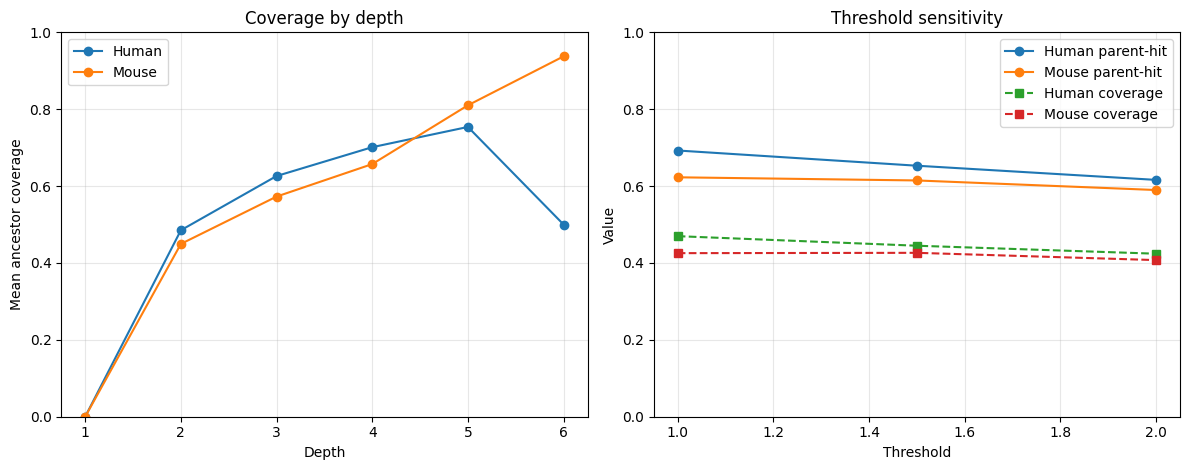

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax1, ax2 = axes

# 左图：coverage by depth
ax1.plot(human_cov_depth_1["depth"], human_cov_depth_1["mean"], marker="o", label="Human")
ax1.plot(mouse_cov_depth_1["depth"], mouse_cov_depth_1["mean"], marker="o", label="Mouse")
ax1.set_title("Coverage by depth")
ax1.set_xlabel("Depth")
ax1.set_ylabel("Mean ancestor coverage")
ax1.set_ylim(0, 1.0)
ax1.legend()
ax1.grid(alpha=0.3)

# 右图：threshold sensitivity
ax2.plot(human_threshold_summary["threshold"], human_threshold_summary["parent_hit_rate"], marker="o", label="Human parent-hit")
ax2.plot(mouse_threshold_summary["threshold"], mouse_threshold_summary["parent_hit_rate"], marker="o", label="Mouse parent-hit")
ax2.plot(human_threshold_summary["threshold"], human_threshold_summary["ancestor_coverage_mean"], marker="s", linestyle="--", label="Human coverage")
ax2.plot(mouse_threshold_summary["threshold"], mouse_threshold_summary["ancestor_coverage_mean"], marker="s", linestyle="--", label="Mouse coverage")
ax2.set_title("Threshold sensitivity")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Value")
ax2.set_ylim(0, 1.0)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

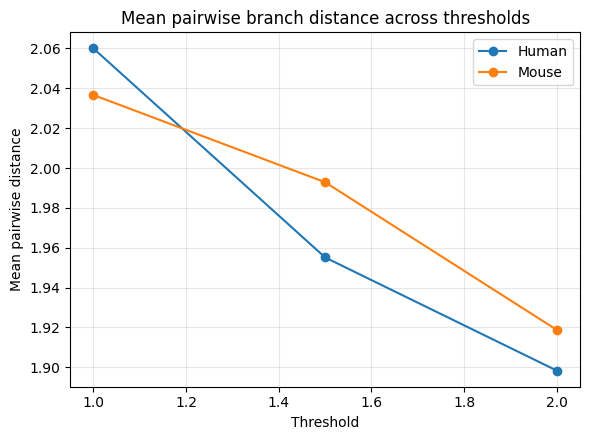

In [33]:
fig, ax = plt.subplots(figsize=(6, 4.5))

ax.plot(
    human_threshold_summary["threshold"],
    human_threshold_summary["mean_pair_dist"],
    marker="o",
    label="Human"
)
ax.plot(
    mouse_threshold_summary["threshold"],
    mouse_threshold_summary["mean_pair_dist"],
    marker="o",
    label="Mouse"
)

ax.set_title("Mean pairwise branch distance across thresholds")
ax.set_xlabel("Threshold")
ax.set_ylabel("Mean pairwise distance")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

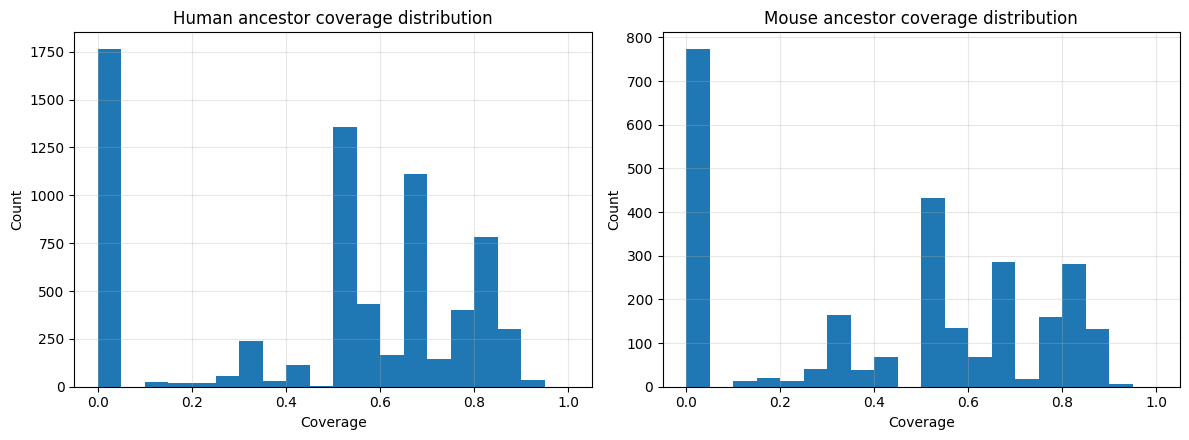

In [34]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax1, ax2 = axes

bins = np.linspace(0, 1, 21)

ax1.hist(human_cov_1["coverage"], bins=bins)
ax1.set_title("Human ancestor coverage distribution")
ax1.set_xlabel("Coverage")
ax1.set_ylabel("Count")
ax1.grid(alpha=0.3)

ax2.hist(mouse_cov_1["coverage"], bins=bins)
ax2.set_title("Mouse ancestor coverage distribution")
ax2.set_xlabel("Coverage")
ax2.set_ylabel("Count")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

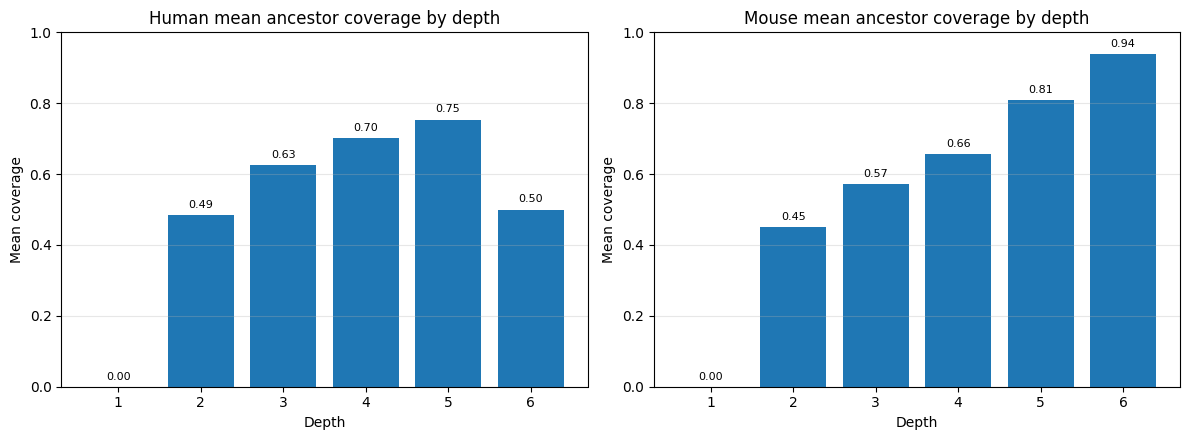

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax1, ax2 = axes

ax1.bar(human_cov_depth_1["depth"], human_cov_depth_1["mean"])
ax1.set_title("Human mean ancestor coverage by depth")
ax1.set_xlabel("Depth")
ax1.set_ylabel("Mean coverage")
ax1.set_ylim(0, 1.0)
ax1.grid(axis="y", alpha=0.3)

for _, r in human_cov_depth_1.iterrows():
    ax1.text(r["depth"], r["mean"] + 0.02, f'{r["mean"]:.2f}', ha="center", fontsize=8)

ax2.bar(mouse_cov_depth_1["depth"], mouse_cov_depth_1["mean"])
ax2.set_title("Mouse mean ancestor coverage by depth")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Mean coverage")
ax2.set_ylim(0, 1.0)
ax2.grid(axis="y", alpha=0.3)

for _, r in mouse_cov_depth_1.iterrows():
    ax2.text(r["depth"], r["mean"] + 0.02, f'{r["mean"]:.2f}', ha="center", fontsize=8)

plt.tight_layout()
plt.show()

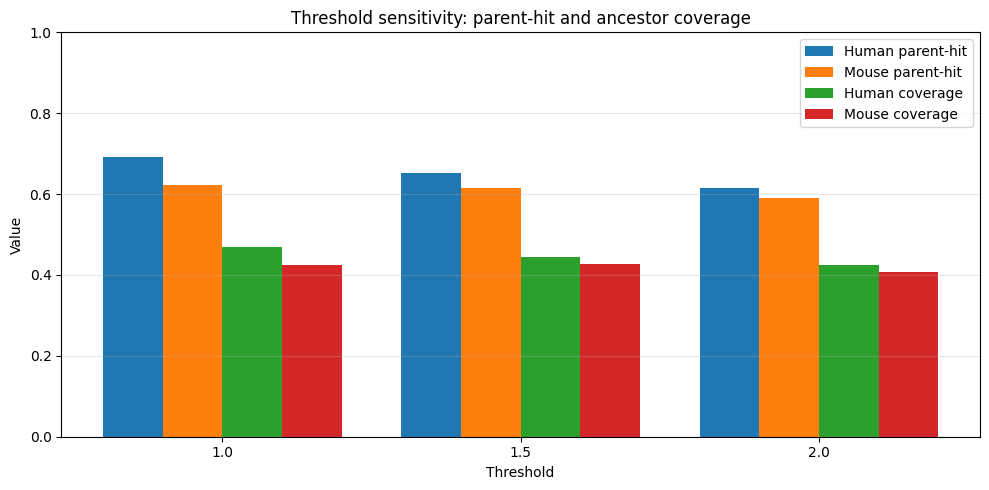

In [36]:
thresholds = human_threshold_summary["threshold"].astype(str).tolist()
x = np.arange(len(thresholds))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - 1.5*width,
    human_threshold_summary["parent_hit_rate"],
    width,
    label="Human parent-hit"
)
ax.bar(
    x - 0.5*width,
    mouse_threshold_summary["parent_hit_rate"],
    width,
    label="Mouse parent-hit"
)
ax.bar(
    x + 0.5*width,
    human_threshold_summary["ancestor_coverage_mean"],
    width,
    label="Human coverage"
)
ax.bar(
    x + 1.5*width,
    mouse_threshold_summary["ancestor_coverage_mean"],
    width,
    label="Mouse coverage"
)

ax.set_xticks(x)
ax.set_xticklabels(thresholds)
ax.set_xlabel("Threshold")
ax.set_ylabel("Value")
ax.set_title("Threshold sensitivity: parent-hit and ancestor coverage")
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

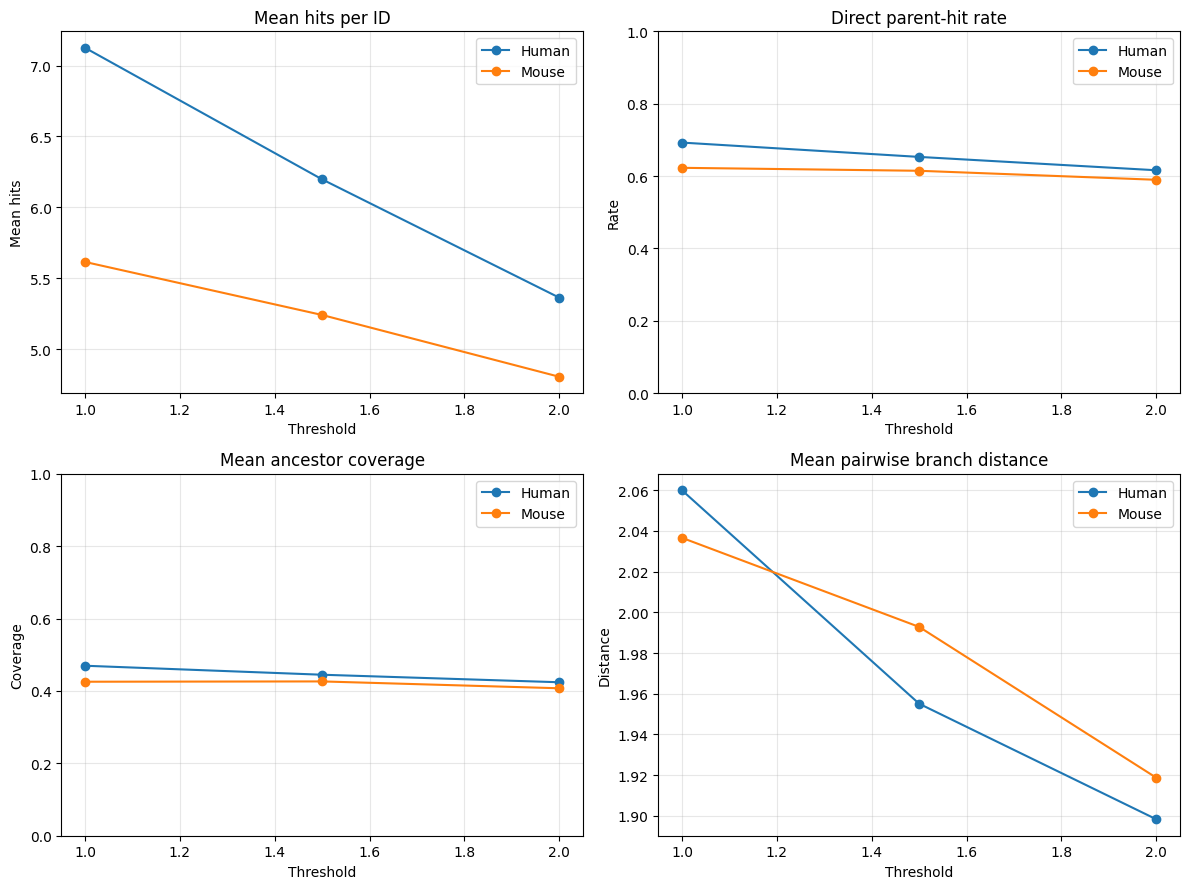

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
ax1, ax2, ax3, ax4 = axes.flatten()

# mean hits per ID
ax1.plot(human_threshold_summary["threshold"], human_threshold_summary["mean_hits_per_id"], marker="o", label="Human")
ax1.plot(mouse_threshold_summary["threshold"], mouse_threshold_summary["mean_hits_per_id"], marker="o", label="Mouse")
ax1.set_title("Mean hits per ID")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Mean hits")
ax1.legend()
ax1.grid(alpha=0.3)

# parent-hit
ax2.plot(human_threshold_summary["threshold"], human_threshold_summary["parent_hit_rate"], marker="o", label="Human")
ax2.plot(mouse_threshold_summary["threshold"], mouse_threshold_summary["parent_hit_rate"], marker="o", label="Mouse")
ax2.set_title("Direct parent-hit rate")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Rate")
ax2.set_ylim(0, 1.0)
ax2.legend()
ax2.grid(alpha=0.3)

# ancestor coverage
ax3.plot(human_threshold_summary["threshold"], human_threshold_summary["ancestor_coverage_mean"], marker="o", label="Human")
ax3.plot(mouse_threshold_summary["threshold"], mouse_threshold_summary["ancestor_coverage_mean"], marker="o", label="Mouse")
ax3.set_title("Mean ancestor coverage")
ax3.set_xlabel("Threshold")
ax3.set_ylabel("Coverage")
ax3.set_ylim(0, 1.0)
ax3.legend()
ax3.grid(alpha=0.3)

# pairwise distance
ax4.plot(human_threshold_summary["threshold"], human_threshold_summary["mean_pair_dist"], marker="o", label="Human")
ax4.plot(mouse_threshold_summary["threshold"], mouse_threshold_summary["mean_pair_dist"], marker="o", label="Mouse")
ax4.set_title("Mean pairwise branch distance")
ax4.set_xlabel("Threshold")
ax4.set_ylabel("Distance")
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

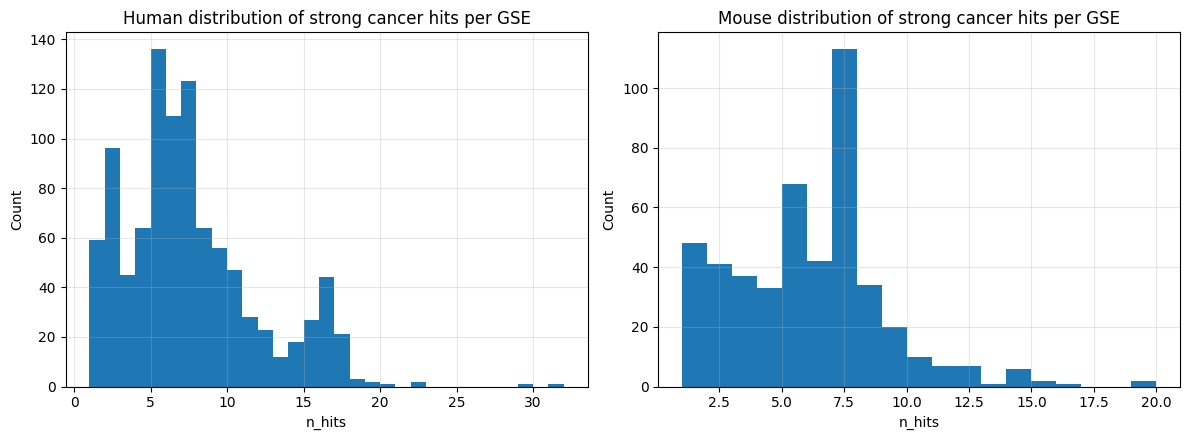

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax1, ax2 = axes

ax1.hist(human_purity_1["n_hits"], bins=range(1, int(human_purity_1["n_hits"].max()) + 2))
ax1.set_title("Human distribution of strong cancer hits per GSE")
ax1.set_xlabel("n_hits")
ax1.set_ylabel("Count")
ax1.grid(alpha=0.3)

ax2.hist(mouse_purity_1["n_hits"], bins=range(1, int(mouse_purity_1["n_hits"].max()) + 2))
ax2.set_title("Mouse distribution of strong cancer hits per GSE")
ax2.set_xlabel("n_hits")
ax2.set_ylabel("Count")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

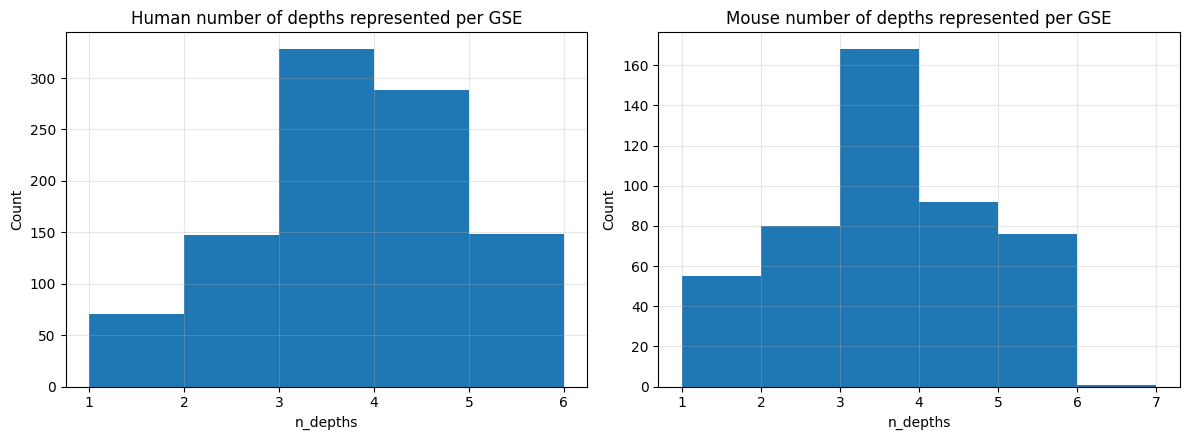

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax1, ax2 = axes

ax1.hist(human_purity_1["n_depths"], bins=range(1, int(human_purity_1["n_depths"].max()) + 2))
ax1.set_title("Human number of depths represented per GSE")
ax1.set_xlabel("n_depths")
ax1.set_ylabel("Count")
ax1.grid(alpha=0.3)

ax2.hist(mouse_purity_1["n_depths"], bins=range(1, int(mouse_purity_1["n_depths"].max()) + 2))
ax2.set_title("Mouse number of depths represented per GSE")
ax2.set_xlabel("n_depths")
ax2.set_ylabel("Count")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

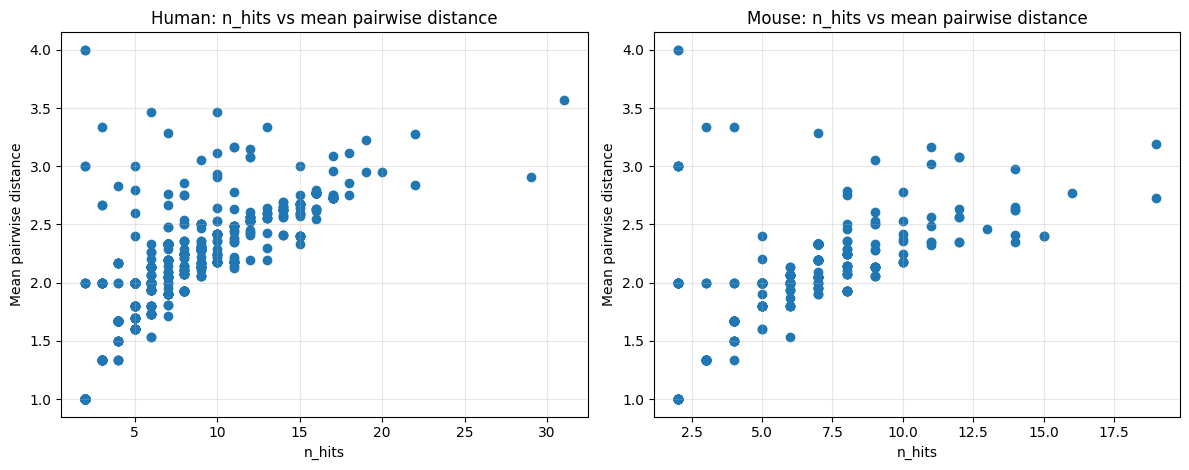

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax1, ax2 = axes

tmp_h = human_purity_1.dropna(subset=["mean_pair_dist"]).copy()
tmp_m = mouse_purity_1.dropna(subset=["mean_pair_dist"]).copy()

ax1.scatter(tmp_h["n_hits"], tmp_h["mean_pair_dist"])
ax1.set_title("Human: n_hits vs mean pairwise distance")
ax1.set_xlabel("n_hits")
ax1.set_ylabel("Mean pairwise distance")
ax1.grid(alpha=0.3)

ax2.scatter(tmp_m["n_hits"], tmp_m["mean_pair_dist"])
ax2.set_title("Mouse: n_hits vs mean pairwise distance")
ax2.set_xlabel("n_hits")
ax2.set_ylabel("Mean pairwise distance")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

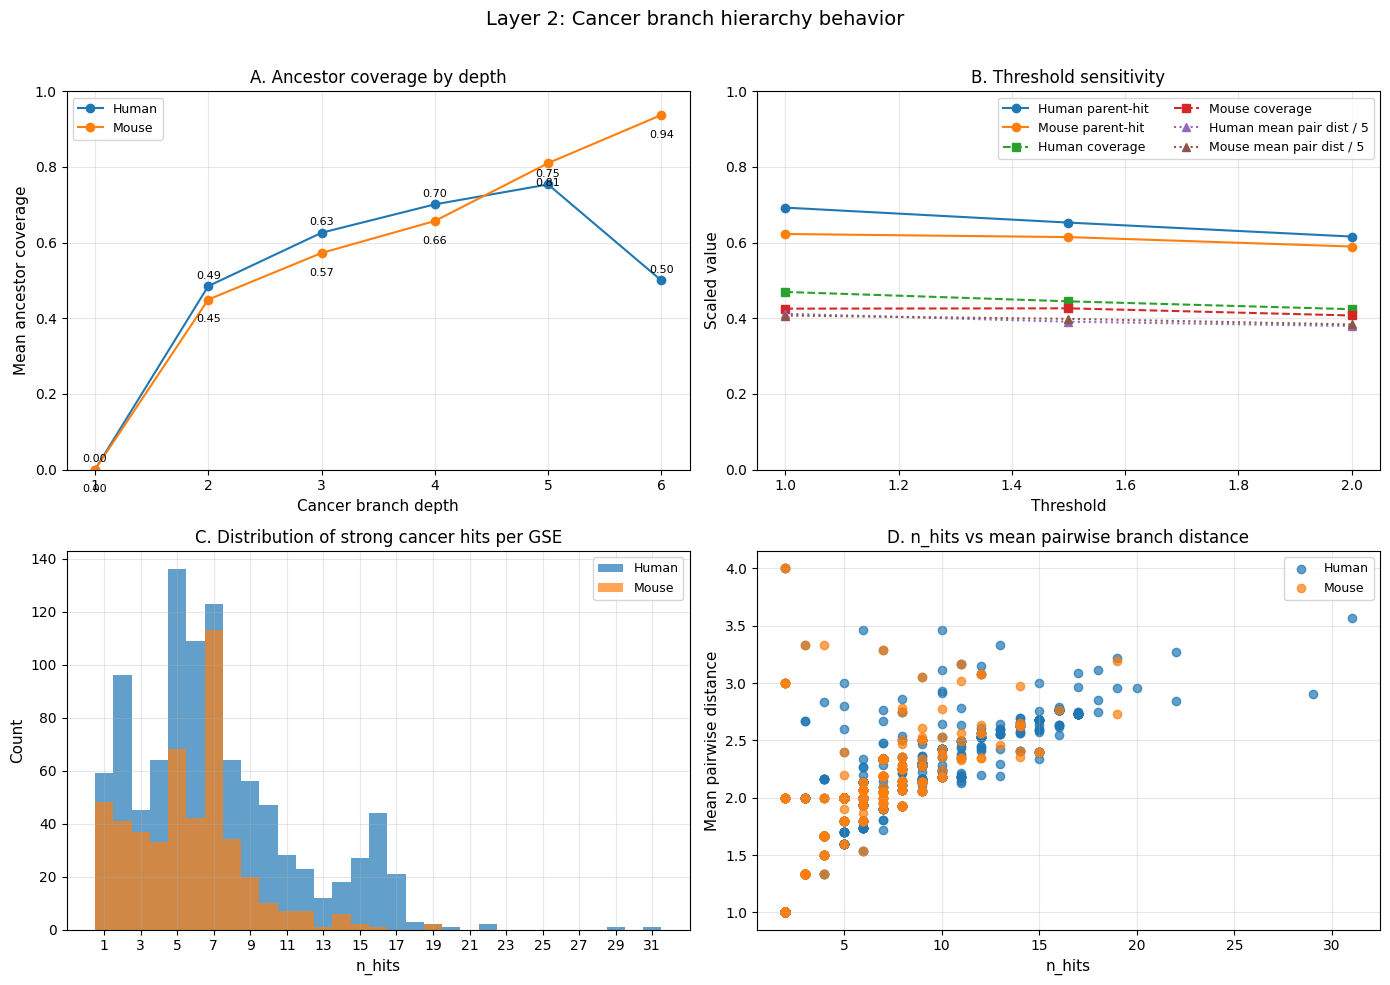

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# 统一风格
# -----------------------------------
plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

# ===================================
# Panel A: coverage by depth
# ===================================
ax1.plot(
    human_cov_depth_1["depth"],
    human_cov_depth_1["mean"],
    marker="o",
    label="Human"
)
ax1.plot(
    mouse_cov_depth_1["depth"],
    mouse_cov_depth_1["mean"],
    marker="o",
    label="Mouse"
)

ax1.set_title("A. Ancestor coverage by depth")
ax1.set_xlabel("Cancer branch depth")
ax1.set_ylabel("Mean ancestor coverage")
ax1.set_ylim(0, 1.0)
ax1.legend()
ax1.grid(alpha=0.3)

# 可选：加数值标签
for _, r in human_cov_depth_1.iterrows():
    ax1.text(
        r["depth"],
        r["mean"] + 0.02,
        f'{r["mean"]:.2f}',
        ha="center",
        fontsize=8
    )

for _, r in mouse_cov_depth_1.iterrows():
    ax1.text(
        r["depth"],
        r["mean"] - 0.06,
        f'{r["mean"]:.2f}',
        ha="center",
        fontsize=8
    )

# ===================================
# Panel B: threshold sensitivity
# 这里画 3 个指标：
# parent_hit_rate, ancestor_coverage_mean, mean_pair_dist
# 用不同 linestyle 区分
# ===================================
ax2.plot(
    human_threshold_summary["threshold"],
    human_threshold_summary["parent_hit_rate"],
    marker="o",
    label="Human parent-hit"
)
ax2.plot(
    mouse_threshold_summary["threshold"],
    mouse_threshold_summary["parent_hit_rate"],
    marker="o",
    label="Mouse parent-hit"
)

ax2.plot(
    human_threshold_summary["threshold"],
    human_threshold_summary["ancestor_coverage_mean"],
    marker="s",
    linestyle="--",
    label="Human coverage"
)
ax2.plot(
    mouse_threshold_summary["threshold"],
    mouse_threshold_summary["ancestor_coverage_mean"],
    marker="s",
    linestyle="--",
    label="Mouse coverage"
)

ax2.plot(
    human_threshold_summary["threshold"],
    human_threshold_summary["mean_pair_dist"] / 5.0,
    marker="^",
    linestyle=":",
    label="Human mean pair dist / 5"
)
ax2.plot(
    mouse_threshold_summary["threshold"],
    mouse_threshold_summary["mean_pair_dist"] / 5.0,
    marker="^",
    linestyle=":",
    label="Mouse mean pair dist / 5"
)

ax2.set_title("B. Threshold sensitivity")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Scaled value")
ax2.set_ylim(0, 1.0)
ax2.legend(ncol=2)
ax2.grid(alpha=0.3)

# ===================================
# Panel C: n_hits distribution
# 用重叠 histogram
# ===================================
human_nhits = human_purity_1["n_hits"].dropna()
mouse_nhits = mouse_purity_1["n_hits"].dropna()

max_hits = int(max(human_nhits.max(), mouse_nhits.max()))
bins = np.arange(1, max_hits + 2) - 0.5

ax3.hist(human_nhits, bins=bins, alpha=0.7, label="Human")
ax3.hist(mouse_nhits, bins=bins, alpha=0.7, label="Mouse")

ax3.set_title("C. Distribution of strong cancer hits per GSE")
ax3.set_xlabel("n_hits")
ax3.set_ylabel("Count")
ax3.set_xticks(range(1, max_hits + 1, max(1, max_hits // 12)))
ax3.legend()
ax3.grid(alpha=0.3)

# ===================================
# Panel D: n_hits vs mean_pair_dist scatter
# ===================================
tmp_h = human_purity_1.dropna(subset=["mean_pair_dist"]).copy()
tmp_m = mouse_purity_1.dropna(subset=["mean_pair_dist"]).copy()

ax4.scatter(
    tmp_h["n_hits"],
    tmp_h["mean_pair_dist"],
    label="Human",
    alpha=0.7
)
ax4.scatter(
    tmp_m["n_hits"],
    tmp_m["mean_pair_dist"],
    label="Mouse",
    alpha=0.7
)

ax4.set_title("D. n_hits vs mean pairwise branch distance")
ax4.set_xlabel("n_hits")
ax4.set_ylabel("Mean pairwise distance")
ax4.legend()
ax4.grid(alpha=0.3)

# -----------------------------------
# 总标题与布局
# -----------------------------------
fig.suptitle("Layer 2: Cancer branch hierarchy behavior", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [44]:
human_cov_1[human_cov_1["depth"] == 6][
    ["ID", "term", "coverage", "n_ancestors", "n_ancestors_hit"]
]

,ID,term,coverage,n_ancestors,n_ancestors_hit
6290,GSE59855,MONDO_0019087,0.5,16,8


metadata disease predictions 在 cancer branch 上形成 hierarchical signal gradient

具体表现为：

- deeper terms → higher specificity
- parents often co-activate
- ancestors partially co-activate
- hit sets form clustered branches rather than random spread
- pattern consistent across human and mouse
- pattern stable across thresholds

## Archive

In [6]:
%pip install rdflib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

THRESH = 1.0

owl_path_candidates = [
    Path("data/mondo_cancer.owl"),
    Path("/mnt/data/mondo_cancer.owl"),
]
owl_path = next((p for p in owl_path_candidates if p.exists()), None)
if owl_path is None:
    raise FileNotFoundError("找不到 mondo_cancer.owl，请确认在 data/ 或 /mnt/data/ 下。")

print("Using OWL:", owl_path)

from rdflib import Graph, URIRef, RDFS

g = Graph()
g.parse(str(owl_path))

# MONDO term URI 通常是 http://purl.obolibrary.org/obo/MONDO_0004992
def uri_to_mondo_id(u: str) -> str | None:
    if "MONDO_" in u:
        return u.split("MONDO_")[-1].split("#")[0].split("/")[0]
    return None

def uri_to_id(u: URIRef) -> str | None:
    s = str(u)
    n = uri_to_mondo_id(s)
    if n is None:
        return None
    return f"MONDO_{n}"

parents = {}  # child -> set(parents)
for child_uri, _, parent_uri in g.triples((None, RDFS.subClassOf, None)):
    c = uri_to_id(child_uri)
    p = uri_to_id(parent_uri)
    if c and p:
        parents.setdefault(c, set()).add(p)

# root（你 extract 的 term）
ROOT = "MONDO_0004992"
print("Root:", ROOT)
print("Terms with parent edges:", len(parents))

Using OWL: data/mondo_cancer.owl
Root: MONDO_0004992
Terms with parent edges: 13


In [8]:
from collections import defaultdict, deque

children = defaultdict(set)
for c, ps in parents.items():
    for p in ps:
        children[p].add(c)

def get_descendants(root):
    seen = set()
    q = deque([root])
    while q:
        cur = q.popleft()
        for ch in children.get(cur, []):
            if ch not in seen:
                seen.add(ch)
                q.append(ch)
    return seen

cancer_desc = get_descendants(ROOT)
cancer_terms = set([ROOT]) | cancer_desc
print("Cancer branch terms (incl root):", len(cancer_terms))

from functools import lru_cache

@lru_cache(maxsize=None)
def ancestors(term: str) -> frozenset:
    ps = parents.get(term, set())
    out = set()
    for p in ps:
        if p in cancer_terms:
            out.add(p)
            out |= set(ancestors(p))
    return frozenset(out)

# quick sanity
print("Example ancestors count for root:", len(ancestors(ROOT)))
some_term = next(iter(cancer_desc)) if cancer_desc else ROOT
print("Example term:", some_term, "ancestors:", len(ancestors(some_term)))

Cancer branch terms (incl root): 1
Example ancestors count for root: 0
Example term: MONDO_0004992 ancestors: 0


In [9]:
from rdflib import Graph, URIRef
import re

g = Graph()
g.parse("data/mondo_cancer.owl")

mondo_ids = set()
for s, p, o in g:
    for node in (s, o):
        m = re.search(r"MONDO_\d+", str(node))
        if m:
            mondo_ids.add(m.group(0))

print("MONDO terms in file:", len(mondo_ids))
print("Has root?", "MONDO_0004992" in mondo_ids)
print("Sample terms:", sorted(list(mondo_ids))[:20])

MONDO terms in file: 15
Has root? True
Sample terms: ['MONDO_0000001', 'MONDO_0002254', 'MONDO_0004992', 'MONDO_0005043', 'MONDO_0005070', 'MONDO_0021058', 'MONDO_0021074', 'MONDO_0021125', 'MONDO_0021126', 'MONDO_0021127', 'MONDO_0021128', 'MONDO_0023370', 'MONDO_0045024', 'MONDO_0045054', 'MONDO_0700096']


# Report
## 研究范围限定

* 以 **MONDO:0004992 (cancer)** 为 root
* 在完整 MONDO 中共有 2270 个癌症相关 term
* txt2onto 仅覆盖其中 261 个（≈11.5%）
* 在 strong 预测（threshold = 1）下：

  * Human: 1680 strong GSE
  * Mouse: 1257 strong GSE

分析仅限于这 261 个**可建模的 cancer 子图**。

---

## 主要发现

### 1️⃣ Ontology 层级方向在语言中是可恢复的

证据：

* generic cancer（depth 0）从未被 strong 选中
* strong 预测主要集中在 depth 2–3
* deeper nodes 的平均 log2(prob/prior) 更高

这说明：

> 模型更容易识别具体 subtype，而不是泛化到 root。
> specificity 在语言统计中是可区分的。

---

### 2️⃣ 语言并不均匀激活 ontology 空间

证据：

* 可建模节点：261
* Human 实际激活：65（≈25%）
* Mouse 实际激活：43（≈16%）

说明：

> 语言仅激活 ontology 子树的一小部分。

---

### 3️⃣ strong 预测高度集中（branch dominance）

证据：

* Top-5 subtype 占比：

  * Human ≈ 43%
  * Mouse ≈ 46%
* Gini：

  * Human ≈ 0.62
  * Mouse ≈ 0.54

说明：

> 近一半 strong 预测集中在 5 个 subtype 上。
> 子树呈现明显“热点疾病”。

---

### 4️⃣ depth 与 activation 频率无单调关系

证据：

* Spearman ρ ≈ -0.20（不显著）

说明：

> 虽然 deeper node score 更高，但并不会更常被选中。
> specificity 提高置信度，但不提高出现频率。

---

### 5️⃣ Human 与 Mouse 的结构差异

* Mouse strong 预测略微更深（mean depth 2.84 vs 2.68）
* Mouse 分布略微更集中（Top-5 share 更高）

说明：

> 两物种在 cancer 语言表达结构上存在差异，但整体模式相似。

---

## 综合结论

在 txt2onto 可建模的 cancer 子树内：

1. Ontology 层级结构在语言统计中是可恢复的（specific > generic）。
2. 语言并不重建完整 ontology，而是选择性激活其中少数 branch。
3. strong 预测呈现明显的压缩与集中效应。
4. specificity 与模型置信度正相关，但不决定出现频率。

因此：

> Ontology 结构在语言中以“选择性压缩”的形式出现，而非完整重构。

---

## Scope

* Root: **MONDO:0004992 (cancer)**
* Full MONDO cancer branch: 2270 terms
* txt2onto model coverage: 261 terms (~11.5%)
* Strong predictions (threshold = 1):

  * Human: 1680 GSEs
  * Mouse: 1257 GSEs

All analysis is restricted to the **model-covered cancer subgraph**.

---

## Key Findings

### 1️⃣ Ontology hierarchy direction is recoverable in language statistics

Evidence:

* Generic cancer (depth 0) is never selected as strong top1
* Strong predictions concentrate at depth 2–3
* Deeper nodes have higher mean log2(prob/prior)

This indicates:

> The model distinguishes specific subtypes rather than collapsing to the root.
> Specificity is statistically recoverable from language.

---

### 2️⃣ Language does not uniformly activate the ontology space

Evidence:

* Available cancer nodes: 261
* Active nodes:

  * Human: 65 (~25%)
  * Mouse: 43 (~16%)

This shows:

> Only a small portion of the model-expressible ontology space is activated in strong predictions.

---

### 3️⃣ Strong predictions exhibit branch dominance

Evidence:

* Top-5 subtype share:

  * Human ≈ 43%
  * Mouse ≈ 46%
* Gini:

  * Human ≈ 0.62
  * Mouse ≈ 0.54

Nearly half of strong predictions are concentrated in five subtypes.

This implies:

> Cancer language is highly concentrated around a few dominant branches.

---

### 4️⃣ Depth does not predict activation frequency

Evidence:

* Spearman ρ ≈ -0.20 (not significant)

This suggests:

> Although deeper nodes have higher confidence scores,
> they are not more frequently selected.

Specificity increases confidence, but not prevalence.

---

### 5️⃣ Structural differences between Human and Mouse

* Mouse strong predictions are slightly deeper on average
* Mouse distribution is slightly more concentrated

This indicates:

> Structural differences exist between species,
> but overall hierarchical patterns are similar.

---

## Overall Interpretation

Within the model-covered cancer subgraph:

1. Ontology hierarchy direction (specific > generic) is statistically recoverable.
2. Language does not reconstruct the full ontology.
3. Instead, it selectively compresses the space into a few dominant branches.
4. Strong predictions reflect structural bias rather than uniform ontology traversal.

Therefore:

> Ontology structure appears in language as selective compression rather than full structural reconstruction.

---

如果你愿意，下一步我们可以：

* 把这个总结转化成论文式 Result section
* 或者正式构造一个 “Ontology Compression Index” 指标
* 或进入 human–mouse alignment 分析

你想往哪边推进？
